# NASA EPSCoR Progress: Hybrid Mach-Zehnder Field Propagation
### 20260629 - *Tyndale Stutzman*
---

## Introduction:

This notebook is intended to serve as a hybrid MZ simulation sandbox for simple Jones calculations. The framework allows for rudimentary schematic editing in order to symbolically determine achievable Poincare Sphere (PS) coverage. <!-- working on turning my doc report into a notebook too -->

## Table of Contents

1. [Step 0: Background](#background)
2. [Step 1: Setup](#setup)
3. [Step 2: Field Propagation](#prop)
4. [Step 3: Calculation](#calc)
5. [Step 4: Analysis](#analysis)


<a id="background"></a>
## Step 0: Background

The initial optical arrangement for this step of the project aims to use EOMs in order to produce an arbitrary polarization state on the output of a Mach-Zehnder interferometer. A beam with polarization characterized by ```Ein``` enters a polarizing beam splitter where one arm is then modulated by an EOM, imparting a phase shift of ```phi_EOM1```. The two beams then enter into a classical Mach-Zehnder interferometer with one arm containing ```EOM2```. 

<div style="display: flex; gap: 20px; align-items: flex-start;">
  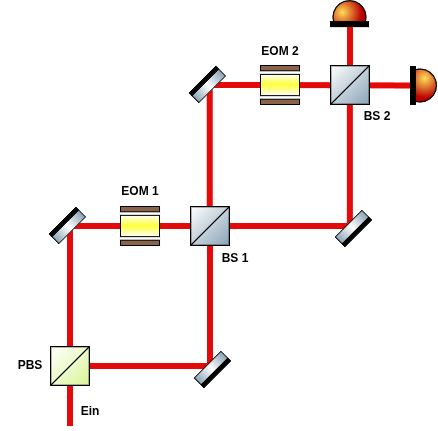

  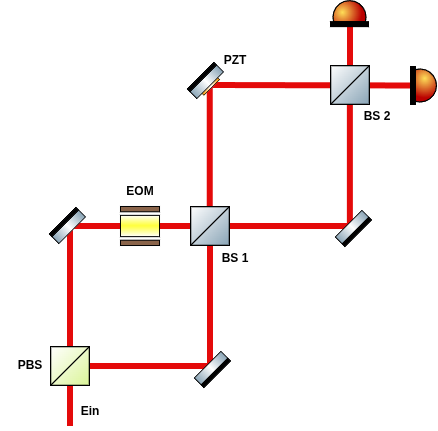
</div>

<a id="setup"></a>
## Step 1: Setup

In [1]:
from sympy import *
from IPython.display import display

init_printing(use_latex="mathjax")

In [2]:
# SYMBOLIC DEFINITIONS

phi, theta, delta = symbols('phi theta delta', real=True)

phi_EOM1 = symbols(r'\phi_{eom}', real=True)
phi_EOM2 = symbols(r'\phi_{2}', real=True)
phi_EOM3 = symbols(r'\phi_{3}', real=True)
phi_PZT1 = symbols(r'\phi_{pzt}', real=True)

Ex, Ey = symbols('E_x E_y', complex=True)

ax, ay = symbols('a_x a_y', real = True)

# Some math definitions:
 
t = 1/sqrt(2)
r = I/sqrt(2)

In [3]:
# INPUT FIELD

# Here Ein is chosen with equal amplitudes where delta = 0 produces a pi/4 linearly polarized beam

Ein = Matrix([
    [ax * exp(I * delta)],
    [ay]
])

display(Ein)

⎡    ⅈ⋅δ⎤
⎢aₓ⋅ℯ   ⎥
⎢       ⎥
⎣  a_y  ⎦

In [4]:
# OPTICAL ELEMENT JONES MATRICES

# Each optical element in the system is defined below.

def Mirror():

    return eye(2)
    

def PBS_T():

    return Matrix([
        [1,0],
        [0,0]
    ])


def PBS_R():

    return Matrix([
        [0,0],
        [0,1]
    ])


def BS(EA, EB):

    t = 1/sqrt(2)
    r = I/sqrt(2)

    EC = simplify(t*EA + r*EB)
    ED = simplify(r*EA + t*EB)

    return EC, ED


def EOM1(phi_EOM1):

    return Matrix([
        [exp(I*phi_EOM1),0],
        [0,1]
    ])

def EOM2(phi_EOM2):

    return Matrix([
        [exp(I*phi_EOM2),0],
        [0,1]
    ])

def EOM3(phi3_EOM3):

    return Matrix([
        [1,0],
        [0,exp(I*phi_EOM3)]
    ])

def PZT(phi_PZT1):

    return Matrix([
        [exp(I*phi_PZT1), 0],
        [0, exp(I*phi_PZT1)]
    ])

In [5]:
# PROPAGATION FUNCTION

def propagate(E, *elements):

    for M in elements:
        E = M * E

    return E

# BEAM SPLITTER COMBINATION FUNCTION

def combine(EA, EB):
    EC = r*EA + t*EB
    ED = r*EB + t*EA
    return EC, ED

<a id="prop"></a>
## Step 2: Field Propagation

This calculation takes the approach of constructing a field for each path between and after beam splitters. For consistency, I have adopted the convention of ```Ex``` being the transmitted path, ```armA```. Notice, each arm takes the incoming Jones Vector and multiplies it by each optical element in that path. 

In [6]:
# PROPAGATE Ein THROUGH INTERFEROMETER

def interferometer(Ein, phi1, phi2):

    armA = propagate(
        Ein,
        PBS_T(),
        Mirror(),
        EOM1(phi1),
    )

    armB = propagate(
        Ein,
        PBS_R(),
        Mirror(),
    )

    armC, armD = combine(armA, armB)

    armC = propagate(
        armC,
        Mirror(),
        PZT(phi_PZT1),
    )

    armD = propagate(
        armD,
        Mirror(),
    )

    armE, armF = combine(armC, armD)
    
    return {
    "armA": armA,
    "armB": armB,
    "armC": armC,
    "armD": armD,
    "armE": armE,
    "armF": armF,
}

In [7]:
# RUN THE INTERFEROMETER FOR EACH ARM

arms = interferometer(Ein, phi_EOM1, phi_EOM2)

display(simplify(arms["armE"]))
print(simplify(arms["armE"]))

⎡   ⎛ ⅈ⋅(\phi_{eom} + δ)    ⅈ⋅(\phi_{eom} + \phi_{pzt} + δ)⎞⎤
⎢aₓ⋅⎝ℯ                   - ℯ                               ⎠⎥
⎢───────────────────────────────────────────────────────────⎥
⎢                             2                             ⎥
⎢                                                           ⎥
⎢                       ⎛ ⅈ⋅\phi_{pzt}    ⎞                 ⎥
⎢                 ⅈ⋅a_y⋅⎝ℯ             + 1⎠                 ⎥
⎢                 ─────────────────────────                 ⎥
⎣                             2                             ⎦

Matrix([[a_x*(exp(I*(\phi_{eom} + delta)) - exp(I*(\phi_{eom} + \phi_{pzt} + delta)))/2], [I*a_y*(exp(I*\phi_{pzt}) + 1)/2]])


<a id="calc"></a>
## Step 3: Calculation

Before numerically manipulating our vectors in python, we can define a chosen coordinate system that allows for a simple mapping from our experimental phase degrees of freedom to angles on the PS. 

### Hybrid MZ PZT + EOM: $(\phi_{\mathrm{eom}},\,\phi_{\mathrm{pzt}})\rightarrow(u,v)$

We begin with the Jones vector describing our desired ouput port, armE,

\begin{equation}
\mathbf{E}
=
\begin{bmatrix}
a_x\left(e^{i(\phi_e+\delta)}-e^{i(\phi_e+\phi_p+\delta)}\right)/2\\[6pt]
i\,a_y\left(e^{i\phi_p}+1\right)/2
\end{bmatrix},
\end{equation}

where $\phi_e$ is the EOM phase, $\phi_p$ is the PZT phase, and $\delta$ is an additional static phase offset.

For the present derivation we assume

\begin{equation}
\delta=0,
\end{equation}

and equal field amplitudes,

\begin{equation}
a_x=a_y=1.
\end{equation}

The Jones vector becomes

\begin{equation}
\mathbf{E}
=
\begin{bmatrix}
\left(e^{i\phi_e}-e^{i(\phi_e+\phi_p)}\right)/2\\[6pt]
i\left(e^{i\phi_p}+1\right)/2
\end{bmatrix}.
\end{equation}

---

## Simplifying the Jones Vector

Factor the exponential in the $x$ component,

\begin{equation}
E_x
=
\frac{e^{i\phi_e}}{2}
\left(1-e^{i\phi_p}\right).
\end{equation}

Using the identity

\begin{equation}
1-e^{i\phi}
=
-2ie^{i\phi/2}\sin\left(\frac{\phi}{2}\right),
\end{equation}

gives

\begin{equation}
E_x
=
-i
e^{i(\phi_e+\phi_p/2)}
\sin\left(\frac{\phi_p}{2}\right).
\end{equation}

Similarly,

\begin{equation}
E_y
=
\frac{i}{2}
\left(1+e^{i\phi_p}\right),
\end{equation}

and using

\begin{equation}
1+e^{i\phi}
=
2e^{i\phi/2}
\cos\left(\frac{\phi}{2}\right),
\end{equation}

gives

\begin{equation}
E_y
=
i
e^{i\phi_p/2}
\cos\left(\frac{\phi_p}{2}\right).
\end{equation}

Both components contain the common factor

\begin{equation}
ie^{i\phi_p/2},
\end{equation}

which is a global phase and therefore has no effect on the polarization state. Removing this global phase yields the equivalent Jones vector

\begin{equation}
\boxed{
\mathbf{E}
\sim
\begin{bmatrix}
-\sin\left(\frac{\phi_p}{2}\right)e^{i\phi_e}\\[6pt]
\cos\left(\frac{\phi_p}{2}\right)
\end{bmatrix}.
}
\end{equation}

---

## Stokes Parameters

For a normalized Jones vector

\begin{equation}
\mathbf{E}
=
\begin{bmatrix}
E_x\\
E_y
\end{bmatrix},
\end{equation}

the normalized Stokes parameters are

\begin{align}
S_1 &= |E_y|^2-|E_x|^2,\\
S_2 &=2\operatorname{Re}(E_xE_y^\ast),\\
S_3 &=2\operatorname{Im}(E_xE_y^\ast).
\end{align}

---

### Calculation of $S_1$

Since

\begin{align}
|E_x|^2
&=
\sin^2\left(\frac{\phi_p}{2}\right),\\
|E_y|^2
&=
\cos^2\left(\frac{\phi_p}{2}\right),
\end{align}

we obtain

\begin{align}
S_1
&=
\cos^2\left(\frac{\phi_p}{2}\right)
-
\sin^2\left(\frac{\phi_p}{2}\right)\\
&=
\boxed{\cos\phi_p.}
\end{align}

---

### Calculation of $S_2$ and $S_3$

First compute

\begin{align}
E_xE_y^\ast
&=
-
\sin\left(\frac{\phi_p}{2}\right)
\cos\left(\frac{\phi_p}{2}\right)
e^{i\phi_e}.
\end{align}

Using

\begin{equation}
2\sin x\cos x=\sin2x,
\end{equation}

gives

\begin{equation}
E_xE_y^\ast
=
-\frac12
\sin\phi_p
e^{i\phi_e}.
\end{equation}

Applying Euler's identity,

\begin{equation}
e^{i\phi_e}
=
\cos\phi_e+i\sin\phi_e,
\end{equation}

yields

\begin{equation}
E_xE_y^\ast
=
-\frac12
\sin\phi_p
\cos\phi_e
-
i
\frac12
\sin\phi_p
\sin\phi_e.
\end{equation}

Taking the real and imaginary parts,

\begin{align}
S_2
&=
2\operatorname{Re}(E_xE_y^\ast)
=
\boxed{
-\sin\phi_p\cos\phi_e,
}\\[6pt]
S_3
&=
2\operatorname{Im}(E_xE_y^\ast)
=
\boxed{
-\sin\phi_p\sin\phi_e.
}
\end{align}

Therefore the normalized Stokes vector is

\begin{equation}
\boxed{
\mathbf{S}
=
\begin{bmatrix}
\cos\phi_p\\
-\sin\phi_p\cos\phi_e\\
-\sin\phi_p\sin\phi_e
\end{bmatrix}.
}
\end{equation}

---

# Spherical Coordinate Parameterization

Rather than using the Stokes components directly, we can define a spherical coordinate system wwhere the polar axis is the $S_1$ axis. This choice is made in part to simplify the determination of polarization states on the $S_1 = 0$ equator. 

Let

- $v$ denote the polar angle measured from the positive $S_1$ axis,
- $u$ denote the azimuthal angle measured in the $(S_2,S_3)$ plane.

Where the corresponding Cartesian coordinates are

\begin{align}
S_1 &= \cos v,\\
S_2 &= \sin v\cos u,\\
S_3 &= \sin v\sin u.
\end{align}

Comparing these expressions with the Stokes vector we derived above,

\begin{align}
\cos v
&=
\cos\phi_p,\\
\sin v\cos u
&=
-\sin\phi_p\cos\phi_e,\\
\sin v\sin u
&=
-\sin\phi_p\sin\phi_e,
\end{align}

we find the coordinate transformation

\begin{equation}
\boxed{
v=\phi_p,
}
\end{equation}

and

\begin{equation}
\boxed{
u=\phi_e+\pi
\quad(\mathrm{mod}\;2\pi).
}
\end{equation}

Thus, under the assumptions of equal field amplitudes, $a_x = a_y$ and zero static phase offset $\delta$ in $E_{in}$, the experimental phase parameters directly parameterize the Poincaré sphere:

\begin{equation}
\boxed{
(u,v)
=
(\phi_e+\pi,\;\phi_p).
}
\end{equation}

In this coordinate system, the PZT phase controls the polar angle on the sphere, while the EOM phase controls the azimuthal rotation about the $S_1$ axis.

In [8]:
# CALCULATION PREREQUISITES

def components(field):

    Ex = field[0]
    Ey = field[1]

    return Ex, Ey


def intensity(field):

    Ex, Ey = components(field)

    return simplify(
        conjugate(Ex)*Ex +
        conjugate(Ey)*Ey
    )

In [9]:
field = arms["armE"]

Ex, Ey = components(field)

Itot = intensity(field)

display(simplify(Itot))

⎛    2      2   ⎛    2  ⅈ⋅\phi_{pzt}       2      2  ⅈ⋅\phi_{pzt}        2⎞  ⅈ ↪
⎝- aₓ  + a_y  + ⎝- aₓ ⋅ℯ             + 2⋅aₓ  + a_y ⋅ℯ             + 2⋅a_y ⎠⋅ℯ  ↪
────────────────────────────────────────────────────────────────────────────── ↪
                                                    4                          ↪

↪ ⋅\phi_{pzt}⎞  -ⅈ⋅\phi_{pzt}
↪            ⎠⋅ℯ             
↪ ───────────────────────────
↪                            

In [10]:
# DEFINE STOKES PARAMETERS

def stokes(field):

    Ex, Ey = components(field)

    S0 = simplify(conjugate(Ex)*Ex + conjugate(Ey)*Ey)

    S1 = simplify(conjugate(Ex)*Ex - conjugate(Ey)*Ey)

    S2 = simplify(2*re(Ex*conjugate(Ey)))

    S3 = simplify(2*im(Ex*conjugate(Ey)))

    return Matrix([
        [S0],
        [S1],
        [S2],
        [S3]
    ])

display(simplify(stokes(field)))

⎡⎛    2      2   ⎛    2  ⅈ⋅\phi_{pzt}       2      2  ⅈ⋅\phi_{pzt}        2⎞   ↪
⎢⎝- aₓ  + a_y  + ⎝- aₓ ⋅ℯ             + 2⋅aₓ  + a_y ⋅ℯ             + 2⋅a_y ⎠⋅ℯ ↪
⎢───────────────────────────────────────────────────────────────────────────── ↪
⎢                                                    4                         ↪
⎢                                                                              ↪
⎢⎛    2      2   ⎛    2  ⅈ⋅\phi_{pzt}       2      2  ⅈ⋅\phi_{pzt}        2⎞   ↪
⎢⎝- aₓ  - a_y  + ⎝- aₓ ⋅ℯ             + 2⋅aₓ  - a_y ⋅ℯ             - 2⋅a_y ⎠⋅ℯ ↪
⎢───────────────────────────────────────────────────────────────────────────── ↪
⎢                                                    4                         ↪
⎢                                                                              ↪
⎢                               -aₓ⋅a_y⋅sin(\phi_{pzt})⋅cos(\phi_{eom} + δ)    ↪
⎢                                                                              ↪
⎣                           

In [11]:
# EVALUATE STOKES VECTOR

field = arms["armE"]

S = stokes(field)

# Choose experimental parameters

S_eval = simplify(
    S.subs({
        ax: 1/sqrt(2), # Normalized amplitude
        ay: 1/sqrt(2),
        delta: 0,
    })
)

display(S_eval)

print(S_eval)

⎡               1/2               ⎤
⎢                                 ⎥
⎢        -cos(\phi_{pzt})         ⎥
⎢        ─────────────────        ⎥
⎢                2                ⎥
⎢                                 ⎥
⎢-sin(\phi_{pzt})⋅cos(\phi_{eom}) ⎥
⎢─────────────────────────────────⎥
⎢                2                ⎥
⎢                                 ⎥
⎢-sin(\phi_{eom})⋅sin(\phi_{pzt}) ⎥
⎢─────────────────────────────────⎥
⎣                2                ⎦

Matrix([[1/2], [-cos(\phi_{pzt})/2], [-sin(\phi_{pzt})*cos(\phi_{eom})/2], [-sin(\phi_{eom})*sin(\phi_{pzt})/2]])


In [13]:
# Confirm S1 = 0 Condition (typically pi or pi/2 depending on architecture)

S_pi = simplify(
    S_eval.subs(phi_PZT1, pi / 2)
)

display(S_pi)

⎡       1/2       ⎤
⎢                 ⎥
⎢        0        ⎥
⎢                 ⎥
⎢-cos(\phi_{eom}) ⎥
⎢─────────────────⎥
⎢        2        ⎥
⎢                 ⎥
⎢-sin(\phi_{eom}) ⎥
⎢─────────────────⎥
⎣        2        ⎦

In [14]:
S_zero = simplify(
    S_eval.subs(phi_PZT1, 0)
)

display(S_zero)

⎡1/2 ⎤
⎢    ⎥
⎢-1/2⎥
⎢    ⎥
⎢ 0  ⎥
⎢    ⎥
⎣ 0  ⎦

### Parameterization

In [16]:
# EVAL CHECK

import numpy as np
from sympy import lambdify, Mod, pi, simplify

phi1_u_expr = simplify(phi1_u)
phi2_u_expr = simplify(Mod(phi2_u, pi))

display(Eq(phi_EOM1, phi1_u_expr))
display(Eq(phi_PZT1, phi2_u_expr))


phi1_of_u = lambdify(u, phi1_u_expr, "numpy")
phi2_of_u = lambdify(u, phi2_u_expr, "numpy")


def get_phis_from_u(u_val):
    return phi1_of_u(u_val), phi2_of_u(u_val)

def wrap_to_pi(x):
    """Wrap angle into (-π, π]."""
    return (x + np.pi) % (2*np.pi) - np.pi

u_val = 0.0

phi1_val, phi2_val = get_phis_from_u(u_val)

print(f"u = {u_val:.3f} rad")
print("phi1 =", wrap_to_pi(phi1_val))
print("phi2 =", phi2_val)          # already reduced modulo π

NameError: name 'phi1_u' is not defined

### Numerical Evaluation

In [354]:
# NUMERICAL FUNCTIONS

from sympy import lambdify
import numpy as np
import matplotlib.pyplot as plt

S_func = lambdify(
    (phi_EOM1, phi_PZT1),
    S_eval,
    modules="numpy"
)

In [355]:
# EVALUATE STOKES NUMERICALLY

def evaluate_stokes(phi1, phi2):

    phi1 = np.asarray(phi1)
    phi2 = np.asarray(phi2)

    phi1, phi2 = np.broadcast_arrays(phi1, phi2)

    S = S_func(phi1, phi2)

    S = np.asarray(S)

    # FORCE consistent shape: (4, N)
    if S.ndim == 2:
        return S
    elif S.ndim == 3:
        return np.squeeze(S)
    else:
        raise ValueError(f"Unexpected shape: {S.shape}")

In [356]:
def normalize_stokes(S):

    S = np.asarray(S)

    S0 = S[0]
    S1 = S[1]
    S2 = S[2]
    S3 = S[3]

    denom = S0

    return np.array([
        S1 / denom,
        S2 / denom,
        S3 / denom
    ])

## Plotting

### 2D S1 = 0

<IPython.core.display.Math object>

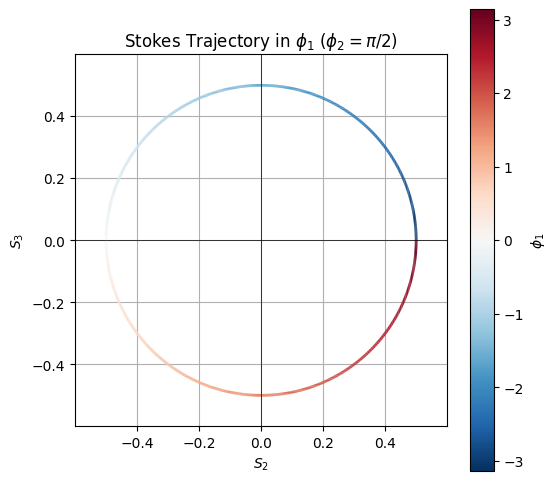

In [357]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from IPython.display import display, Math


phi2_fixed = np.pi / 2

display(Math(r"\phi_1 \mapsto (S_2(\phi_1,\phi_2=\pi/2),\; S_3(\phi_1,\phi_2=\pi/2))"))

phi1_vals = np.linspace(-np.pi, np.pi, 1000)

S2_vals = []
S3_vals = []

for phi1 in phi1_vals:

    # use fixed φ2 = π/2
    S = S_func(phi1, phi2_fixed)
    S = np.squeeze(S)

    S2_vals.append(S[2])
    S3_vals.append(S[3])

S2_vals = np.array(S2_vals)
S3_vals = np.array(S3_vals)


points = np.array([S2_vals, S3_vals]).T.reshape(-1, 1, 2)
segments = np.concatenate([points[:-1], points[1:]], axis=1)

# color by phi1
norm = plt.Normalize(phi1_vals.min(), phi1_vals.max())
lc = LineCollection(segments, cmap='RdBu_r', norm=norm)
lc.set_array(phi1_vals)
lc.set_linewidth(2)


fig, ax = plt.subplots(figsize=(6, 6))
ax.add_collection(lc)

x_margin = 0.1 * (S2_vals.max() - S2_vals.min())
y_margin = 0.1 * (S3_vals.max() - S3_vals.min())

ax.set_xlim(S2_vals.min() - x_margin, S2_vals.max() + x_margin)
ax.set_ylim(S3_vals.min() - y_margin, S3_vals.max() + y_margin)

ax.set_xlabel(r"$S_2$")
ax.set_ylabel(r"$S_3$")
ax.set_title(r"Stokes Trajectory in $\phi_1$ ($\phi_2 = \pi/2$)")

ax.axhline(0, color='black', linewidth=0.5)
ax.axvline(0, color='black', linewidth=0.5)

ax.set_aspect('equal')
ax.grid(True)

cbar = fig.colorbar(lc, ax=ax)
cbar.set_label(r"$\phi_1$")

plt.show()

### 3D

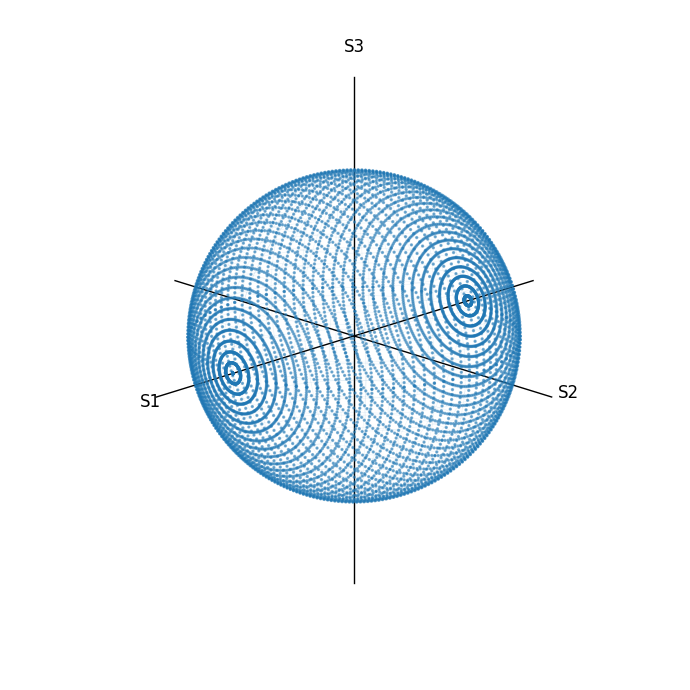

In [358]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401


S1_grid, S2_grid, S3_grid = [], [], []

phi1_vals = np.linspace(-np.pi, np.pi, 100)
phi2_vals = np.linspace(-np.pi, np.pi, 100)

for p1 in phi1_vals:
    for p2 in phi2_vals:

        S = np.squeeze(S_func(p1, p2))
        S0, S1, S2, S3 = S

        if np.abs(S0) < 1e-12:
            continue

        vec = np.array([S1, S2, S3]) / S0
        vec = np.real(vec)

        S1_grid.append(vec[0])
        S2_grid.append(vec[1])
        S3_grid.append(vec[2])

Sx = np.array(S1_grid)
Sy = np.array(S2_grid)
Sz = np.array(S3_grid)


fig = plt.figure(figsize=(7, 7))
ax = fig.add_subplot(111, projection='3d')

# REMOVE ALL BOX / PANES
ax.set_axis_off()


ax.scatter(Sx, Sy, Sz, s=2, alpha=0.5)


u = np.linspace(0, 2*np.pi, 60)
v = np.linspace(0, np.pi, 30)

xs = np.outer(np.cos(u), np.sin(v))
ys = np.outer(np.sin(u), np.sin(v))
zs = np.outer(np.ones_like(u), np.cos(v))

ax.plot_wireframe(xs, ys, zs, alpha=0.08, linewidth=0.5)

axis_len = 1.6

# S1 axis
ax.plot([-axis_len, axis_len], [0, 0], [0, 0], color='black', linewidth=1)
ax.text(axis_len * 1.08, 0, 0, "S1", fontsize=12, ha='left', va='center')

# S2 axis
ax.plot([0, 0], [-axis_len, axis_len], [0, 0], color='black', linewidth=1)
ax.text(0, axis_len * 1.08, 0, "S2", fontsize=12, ha='center', va='bottom')

# S3 axis
ax.plot([0, 0], [0, 0], [-axis_len, axis_len], color='black', linewidth=1)
ax.text(0, 0, axis_len * 1.08, "S3", fontsize=12, ha='center', va='bottom')


ax.set_xlim(-1.2, 1.2)
ax.set_ylim(-1.2, 1.2)
ax.set_zlim(-1.2, 1.2)
ax.set_box_aspect([1, 1, 1])

# no labels, no ticks
ax.set_xticks([])
ax.set_yticks([])
ax.set_zticks([])

ax.view_init(elev=18, azim=45)

plt.tight_layout()
plt.show()